In [3]:
# set cwd
import sys
import os
# Tweak to ensure cwd is at root of repo
os.chdir('..')
print(os.getcwd())

c:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [4]:
#imports
from typing import (
    Sequence,
    List,
    Tuple,
    Optional,
    Set,
    Dict,
)
from collections import defaultdict
import networkx as nx
import timeit
from src.utils.qccd_nodes import *
from src.utils.qccd_operations import *
from src.utils.qccd_operations_on_qubits import *
from src.utils.qccd_arch import *
from src.compiler.qccd_ion_routing import *
from src.compiler.qccd_alt_ion_routing import *

In [ ]:
def _determineRouted(ion1:Ion, ion2:Ion):
    """ Determines the ion that will be routed between the pair """
    if ion1.label[0]==ion2.label[0]:
        # Same type - tiebreak with index
        r_ion, s_ion = sorted(
            (ion1, ion2), key=lambda ion: ion.idx
        )
    else:
        # prioritise routing ancilla otherwise
        r_ion, s_ion = sorted(
            (ion1, ion2), key=lambda ion: ion.label[0]=="D"
        )

    return (r_ion, s_ion)
    
def naiveAltIonRouting3(
    qccdArch: QCCDArch,
    operations: Sequence[QubitOperation],
    trapCapacity: int
) -> Tuple[Sequence[Operation], Sequence[int]]:

    twoQubitGates: defaultdict[int, List[TwoQubitMSGate]] = defaultdict(list)
    print(f"operations = {operations}")
    for op in operations:
        for ion in op.ions:
            print(f"ion = {ion}")
            print(f"trap = {ion.parent}")
        if isinstance(op, TwoQubitMSGate):
            # routed and stationary ion
            # give preference to route ancilla 
            r_ion, s_ion = _determineRouted(*op.ions)

            trap = r_ion.parent
            twoQubitGates[r_ion.idx].append(op)

    opPriorities: Dict[Operation, int] = {op:i for i, op in enumerate(operations)}

    allOps: List[Operation] = []
    barriers: List[int] = []
    operationsRemaining = list(operations)
    toMoveCandidates: Dict[int, TwoQubitMSGate] = {}
    while operationsRemaining:
        print(f"Operations left: {len(operationsRemaining)}")
        
        # Find and run ops that don't need routing
        while True:
            print("Finding ops that don't need routing")
            toRemove: List[Operation] = []
            ionsInvolved: Set[Ion] = set()
            for op in operationsRemaining:
                #for i in op.ions:
                    #print(i.parent)
                #print(f"Processing operation: {op}")
                trap = op.getTrapForIons()
                if ionsInvolved.isdisjoint(op.ions) and trap:
                    op.setTrap(trap)
                    toRemove.append(op)
                ionsInvolved = ionsInvolved.union(op.ions)

            for op in toRemove:
                op.run()
                allOps.append(op)
                operationsRemaining.remove(op)
                print(f"Removing operation: {op}")
                if isinstance(op, TwoQubitMSGate):
                    r_ion, s_ion = _determineRouted(*op.ions)
                    twoQubitGates[r_ion.idx].remove(op)

            if len(toRemove) == 0:
                break
        print(f"toRemove = {toRemove}")
        
        """# Find the ops that need routing - check against if non-routing one also moving
        for rIdx, ops in twoQubitGates.items():
            if len(twoQubitGates[rIdx]) == 0:
                continue
            # dodgy logic - assumes ops not empty atm and that its first op will be done first
            r_idx, s_idx = (i.idx for i in _determineRouted(*ops[0].ions))
            if r_idx in toMoveCandidates or s_idx in toMoveCandidates:
                continue
            gate = twoQubitGates[r_idx][0]
            trap = gate.getTrapForIons()
            if trap:
                continue
            toMoveCandidates[r_idx] = twoQubitGates[r_idx].pop(0)
        """
        for rIdx in twoQubitGates.keys():
            if rIdx in toMoveCandidates:
                continue
            if len(twoQubitGates[rIdx]) == 0:
                continue
            gate = twoQubitGates[rIdx][0]
            trap = gate.getTrapForIons()
            if trap:
                # Skip if ions in the same trap for gate op
                continue
            toMoveCandidates[rIdx] = twoQubitGates[rIdx].pop(0)

        # Move ops with original happens-before priority (oldest first)
        toMove = sorted([(k,o) for k,o in toMoveCandidates.items()], key = lambda ko: opPriorities[ko[1]])
        print(f"toMove = {len(toMove)}")
        usedCrossings: Set[Crossing] = set()
        fullQccdNodes: Set[QCCDNode] = set()
        # routedIdx: op, pathChosen, destinationTrap, goBack
        movements: Dict[int, Tuple[TwoQubitMSGate, List[QCCDNode], Trap]] = {}

        #determining path each routing operation should take
        for rIdx, op in toMove:
            r_ion, s_ion = _determineRouted(*op.ions)
            print(r_ion, s_ion)
            # destination trap (where stationary ion is)
            trap = s_ion.parent
            if not isinstance(trap, Trap):
                raise ValueError(f"Data Ion not in trap {trap}")

            src = rIdx
            dest = trap.idx
            print(f"Attempting to route operation: {op}, from {src} to {dest}")
            paths = list(nx.all_shortest_paths(qccdArch.graph, src, dest))

            chosenQccdNodes: List[QCCDNode] = []
            chosenCrossings: List[Crossing] = []

            # choosing possible routing path
            for path in paths:
                crossingsInPath: List[Crossing] = []
                print(f"Evaluating path: {path}")
                #print(f"Crossings in path: {crossingsInPath}")
                #print(f"Nodes in path: {qccdNodesInPath}")
                # iterate over adjacent pairs in path
                for n1, n2 in zip(path[:-1], path[1:]):
                    if (n1, n2) not in qccdArch.crossingEdges:
                        continue
                    crossingsInPath.append(qccdArch.crossingEdges[(n1,n2)])

                qccdNodesInPath: List[QCCDNode] = []
                for n in path:
                    nd = qccdArch.nodes[n] if n in qccdArch.nodes else qccdArch.ions[n].parent
                    if nd not in qccdNodesInPath:
                        qccdNodesInPath.append(nd)
                    
                #qccdNodesInPathFull: List[QCCDNode] = []

                qccdNodesInPathFull = {
                    qccdNode
                    for qccdNode in qccdNodesInPath[1:]
                    if (isinstance(qccdNode, Junction) and qccdNode.numIons == 1) or (qccdNode.numIons == trapCapacity)
                }
                """
                for qccdNode in qccdNodesInPath[1:]:
                    if isinstance(qccdNode, Junction) and qccdNode.numIons == 1:
                        qccdNodesInPathFull.append(qccdNode)
                    elif qccdNode.numIons == trapCapacity:
                        qccdNodesInPathFull.append(qccdNode)"""

                # Choose path if no overlap with full nodes + used crossings
                if usedCrossings.isdisjoint(crossingsInPath) and fullQccdNodes.isdisjoint(qccdNodesInPathFull):
                    chosenQccdNodes = qccdNodesInPath
                    chosenCrossings = crossingsInPath
                    break

            # can't do move ops
            if len(chosenQccdNodes) == 0:
                continue

            # able to do move op
            toMoveCandidates.pop(rIdx)
            movements[rIdx] = (op, chosenQccdNodes, trap)

            # remove reserved crossings
            usedCrossings = usedCrossings.union(chosenCrossings)

            # increment traps + juncs by 1 ion + remove traps + juncs at capacity
            for qccdNode in chosenQccdNodes[1:]:
                qccdNode.numIons += 1
                if isinstance(qccdNode, Junction) and qccdNode.numIons == 1:
                    fullQccdNodes.add(qccdNode)
                elif qccdNode.numIons == trapCapacity:
                    fullQccdNodes.add(qccdNode)

        # send back routed ion to og trap
        toForward: Dict[TwoQubitMSGate, Tuple[int, List[QCCDNode], Trap, Optional[Trap]]] = {}
        for rIdx, (op, qccdNodes, destTrap) in movements.items():
            goBackTrap = qccdNodes[0]
            # naive impl reroute ion back to original trap 
            """for nd in qccdNodes[::-1][:-1]:
                if nd.numIons <= trapCapacity-1 and isinstance(nd, Trap):
                    goBackTrap = nd"""
            destTrap.numIons -= 1

            toForward[op] = (rIdx, qccdNodes, goBackTrap)

        startedGoingBack = {op:False for op in toForward.keys()}
        # forwarding the ions and sending them back after running operation
        while toForward:
            progress_made = False
            ionsInvolved = set()
            orderedToForward = sorted([(o, rc) for o, rc in toForward.items()], key=lambda orc: opPriorities[orc[0]])
            for op, (rIdx, qccdNodes, goBackTrap) in orderedToForward:
                if not ionsInvolved.isdisjoint(op.ions):
                    continue

           
                r_idx, s_idx = (i.idx for i in _determineRouted(*op.ions))
                # include stationary ion (to ensure it is actually stationary
                ionsInvolvedNow = [qccdArch.ions[r_idx], qccdArch.ions[s_idx]]

                n1 = rIdx
                #index of the trap the routing ion is in 
                n1Idx = qccdArch.ions[rIdx].parent.idx
                #index of the destination trap
                trap = qccdNodes[-1]
                srcTrap = goBackTrap

                # arrived at stationary ion's trap and haven't ran operation yet
                if n1Idx == trap.idx and not startedGoingBack[op]:
                    print("")
                    op.setTrap(trap)
                    try: 
                        op.run()
                    except:
                        fig, ax = plt.subplots()
                        arch.display(fig,ax, showLabels=True)
                        print(f" stats after failure, op ions {[i.idx for i in op.ions]}, op = {op}, qccdNodes = {[n.idx for n in qccdNodes]}, goBackTrap = {goBackTrap.idx}, op.ion.trap = {op.ions[0].parent.idx, op.ions[1].parent.idx}")
                        raise ValueError("first error")
                    allOps.append(op)
                    operationsRemaining.remove(op)
                    ionsInvolved = ionsInvolved.union(op.ions)
                    progress_made = True
                    if goBackTrap is not None:
                        startedGoingBack[op] = True
                    else:
                        toForward.pop(op)
                        continue
                # have ran operation, started going back and arrived at start trap 
                elif startedGoingBack[op] and n1Idx == srcTrap.idx:
                    progress_made = True
                    toForward.pop(op)
                    continue

                # op has run started going back (or hasn't - needs to be routed)
                if startedGoingBack[op]:
                    n2Idx = [dn.idx for sn, dn in zip(qccdNodes[::-1][:-1], qccdNodes[::-1][1:]) if sn.idx == n1Idx][0]
                else:
                    n2Idx = [dn.idx for sn, dn in zip(qccdNodes[:-1], qccdNodes[1:]) if sn.idx == n1Idx][0]
                forwardingPath = nx.shortest_path(qccdArch.graph, n1, n2Idx)
                ms: List[Operation] = []
                for n1, n2 in zip(forwardingPath[:-1], forwardingPath[1:]):
                    ms.extend(qccdArch.graph.edges[n1,n2]["operations"])

                for m in ms:
                    if isinstance(m, CrystalOperation):
                        ionsInvolvedNow.extend(m.ionsInfluenced)
                    if isinstance(m, GateSwap) and m._ion1==m._ion2:
                        continue
                    m.run()
                    allOps.append(m)
                    
                progress_made = True
                qccdArch.refreshGraph()
                ionsInvolved = ionsInvolved.union(ionsInvolvedNow)
                
            if not progress_made:
                raise RuntimeError("Deadlock in ion return logic: circular deps")
            
        barriers.append(len(allOps))

    return allOps, barriers

In [6]:
def naiveAltIonRouting2(
    qccdArch: QCCDArch,
    operations: Sequence[QubitOperation],
    trapCapacity: int
) -> Tuple[Sequence[Operation], Sequence[int]]:

    twoQubitGates: defaultdict[int, Tuple[int, List[Tuple[int,TwoQubitMSGate]]]] = defaultdict(list)
    #stores r_idx: [(s_idx, op), ...]
    
    for op in operations:
        if isinstance(op, TwoQubitMSGate):
            # routed and stationary ion
            # give preference to route ancilla 
            r_ion, s_ion = _determineRouted(*op.ions)
            trap = r_ion.parent
            twoQubitGates[r_ion.idx].append((s_ion.idx, op))

    opPriorities: Dict[Operation, int] = {op:i for i, op in enumerate(operations)}

    allOps: List[Operation] = []
    barriers: List[int] = []
    operationsRemaining = list(operations)
    toMoveCandidates: Dict[int, TwoQubitMSGate] = {}
    ionReserved: defaultdict[int, bool] = defaultdict(bool)
    while operationsRemaining:
        print(len(operationsRemaining))
        # Find and run ops that don't need routing
        while True:
            toRemove: List[Operation] = []
            ionsInvolved: Set[Ion] = set()
            for op in operationsRemaining:
                trap = op.getTrapForIons()
                if ionsInvolved.isdisjoint(op.ions) and trap:
                    op.setTrap(trap)
                    toRemove.append(op)
                ionsInvolved = ionsInvolved.union(op.ions)

            for op in toRemove:
                op.run()
                allOps.append(op)
                operationsRemaining.remove(op)
                if isinstance(op, TwoQubitMSGate):
                    r_ion, s_ion = _determineRouted(*op.ions)
                    twoQubitGates[r_ion.idx].remove((s_ion.idx, op))

            if len(toRemove) == 0:
                break

        for rIdx in twoQubitGates.keys():
            if rIdx in toMoveCandidates:
                continue
            if len(twoQubitGates[rIdx]) == 0:
                continue
            sIdx, gate = twoQubitGates[rIdx][0]
            if sIdx in toMoveCandidates or ionReserved[sIdx]:
                continue
            ionReserved[sIdx] = True
            trap = gate.getTrapForIons()
            if trap:
                # Skip if ions in the same trap for gate op
                continue
            #operation not moved into toMoveCandidates if sIon reserved or going to be moved
            toMoveCandidates[rIdx] = twoQubitGates[rIdx].pop(0)[1]

        # Move ops with original happens-before priority (oldest first)
        toMove = sorted([(k,o) for k,o in toMoveCandidates.items()], key = lambda ko: opPriorities[ko[1]])
        usedCrossings: Set[Crossing] = set()
        fullQccdNodes: Set[QCCDNode] = set()
        movements: Dict[int, Tuple[TwoQubitMSGate, List[QCCDNode], Trap]] = {}
        # routedIdx: op, pathChosen, destinationTrap, goBackTrap

        #determining path each routing operation should take
        for rIdx, op in toMove:
            r_ion, s_ion = _determineRouted(*op.ions)
            # destination trap (where stationary ion is)
            trap = s_ion.parent
            if not isinstance(trap, Trap):
                raise ValueError(f"Data Ion not in trap {trap}")

            src = rIdx
            dest = trap.idx
            paths = list(nx.all_shortest_paths(qccdArch.graph, src, dest))

            chosenQccdNodes: List[QCCDNode] = []
            chosenCrossings: List[Crossing] = []

            # choosing possible routing path
            for path in paths:
                crossingsInPath: List[Crossing] = []
                # iterate over adjacent pairs in path
                for n1, n2 in zip(path[:-1], path[1:]):
                    if (n1, n2) not in qccdArch.crossingEdges:
                        continue
                    crossingsInPath.append(qccdArch.crossingEdges[(n1,n2)])

                qccdNodesInPath: List[QCCDNode] = []
                for n in path:
                    nd = qccdArch.nodes[n] if n in qccdArch.nodes else qccdArch.ions[n].parent
                    if nd not in qccdNodesInPath:
                        qccdNodesInPath.append(nd)

                qccdNodesInPathFull = {
                    qccdNode
                    for qccdNode in qccdNodesInPath[1:]
                    if (isinstance(qccdNode, Junction) and qccdNode.numIons == 1) or (qccdNode.numIons == trapCapacity)
                }

                # Choose path if no overlap with full nodes + used crossings
                if usedCrossings.isdisjoint(crossingsInPath) and fullQccdNodes.isdisjoint(qccdNodesInPathFull):
                    chosenQccdNodes = qccdNodesInPath
                    chosenCrossings = crossingsInPath
                    break

            # can't do move ops
            if len(chosenQccdNodes) == 0:
                continue

            # able to do move op
            toMoveCandidates.pop(rIdx)
            movements[rIdx] = (op, chosenQccdNodes, trap)

            # remove reserved crossings
            usedCrossings = usedCrossings.union(chosenCrossings)

            # increment traps + juncs by 1 ion + remove traps + juncs at capacity
            for qccdNode in chosenQccdNodes[1:]:
                qccdNode.numIons += 1
                if isinstance(qccdNode, Junction) and qccdNode.numIons == 1:
                    fullQccdNodes.add(qccdNode)
                elif qccdNode.numIons == trapCapacity:
                    fullQccdNodes.add(qccdNode)

        # send back routed ion to og trap
        toForward: Dict[TwoQubitMSGate, Tuple[int, List[QCCDNode], Trap, Optional[Trap]]] = {}
        for rIdx, (op, qccdNodes, destTrap) in movements.items():
            goBackTrap = qccdNodes[0]
            # naive impl reroute ion back to original trap 
            destTrap.numIons -= 1
            toForward[op] = (rIdx, qccdNodes, goBackTrap)

        startedGoingBack = {op:False for op in toForward.keys()}
        # forwarding the ions and sending them back after running operation
        while toForward:
            ionsInvolved = set()
            orderedToForward = sorted([(o, rc) for o, rc in toForward.items()], key=lambda orc: opPriorities[orc[0]])
            for op, (rIdx, qccdNodes, goBackTrap) in orderedToForward:
                if not ionsInvolved.isdisjoint(op.ions):
                    continue

                r_idx, s_idx = (i.idx for i in _determineRouted(*op.ions))
                # include stationary ion (to ensure it is actually stationary
                ionsInvolvedNow = [qccdArch.ions[r_idx], qccdArch.ions[s_idx]]

                n1 = rIdx
                #index of the trap the routing ion is in 
                n1Idx = qccdArch.ions[rIdx].parent.idx
                #index of the destination trap
                trap = qccdNodes[-1]
                srcTrap = goBackTrap

                # arrived at stationary ion's trap and haven't ran operation yet
                if n1Idx == trap.idx and not startedGoingBack[op]:
                    op.setTrap(trap)
                    op.run()
                    ionReserved[s_idx] = False
                    allOps.append(op)
                    operationsRemaining.remove(op)
                    ionsInvolved = ionsInvolved.union(op.ions)
                    if goBackTrap is not None:
                        startedGoingBack[op] = True
                    else:
                        toForward.pop(op)
                        continue
                # have ran operation, started going back and arrived at start trap 
                elif startedGoingBack[op] and n1Idx == srcTrap.idx:
                    toForward.pop(op)
                    continue

                # op has run started going back (or hasn't - needs to be routed)
                if startedGoingBack[op]:
                    n2Idx = [dn.idx for sn, dn in zip(qccdNodes[::-1][:-1], qccdNodes[::-1][1:]) if sn.idx == n1Idx][0]
                else:
                    n2Idx = [dn.idx for sn, dn in zip(qccdNodes[:-1], qccdNodes[1:]) if sn.idx == n1Idx][0]
                forwardingPath = nx.shortest_path(qccdArch.graph, n1, n2Idx)
                
                ms: List[Operation] = []
                for n1, n2 in zip(forwardingPath[:-1], forwardingPath[1:]):
                    ms.extend(qccdArch.graph.edges[n1,n2]["operations"])

                for m in ms:
                    if isinstance(m, CrystalOperation):
                        ionsInvolvedNow.extend(m.ionsInfluenced)
                    if isinstance(m, GateSwap) and m._ion1==m._ion2:
                        continue
                    m.run()
                    allOps.append(m)
                    
                qccdArch.refreshGraph()
                ionsInvolved = ionsInvolved.union(ionsInvolvedNow)

        barriers.append(len(allOps))

    return allOps, barriers

c:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


instr n = 7
DiGraph with 171 nodes and 424 edges
ions in arch: {41: <src.utils.qccd_nodes.QubitIon object at 0x000001E32E7C0EC0>, 42: <src.utils.qccd_nodes.QubitIon object at 0x000001E32E7BE490>}
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[<src.utils.qccd_nodes.QubitIon object at 0x000001E32E7C0EC0>, <src.utils.qccd_nodes.QubitIon object at 0x000001E32E7BE490>]
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x000001E32E806BA0>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x000001E32E806BA0>
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
2
measurements = [], datas = [<src.utils.qccd_nodes.QubitIon object at 0x000001E32E7C0EC0>, <src.utils.qccd_nodes.QubitIon object at 0x000001E32E7BE490>]
finished processing
running routi

NameError: name '_determineRouted' is not defined

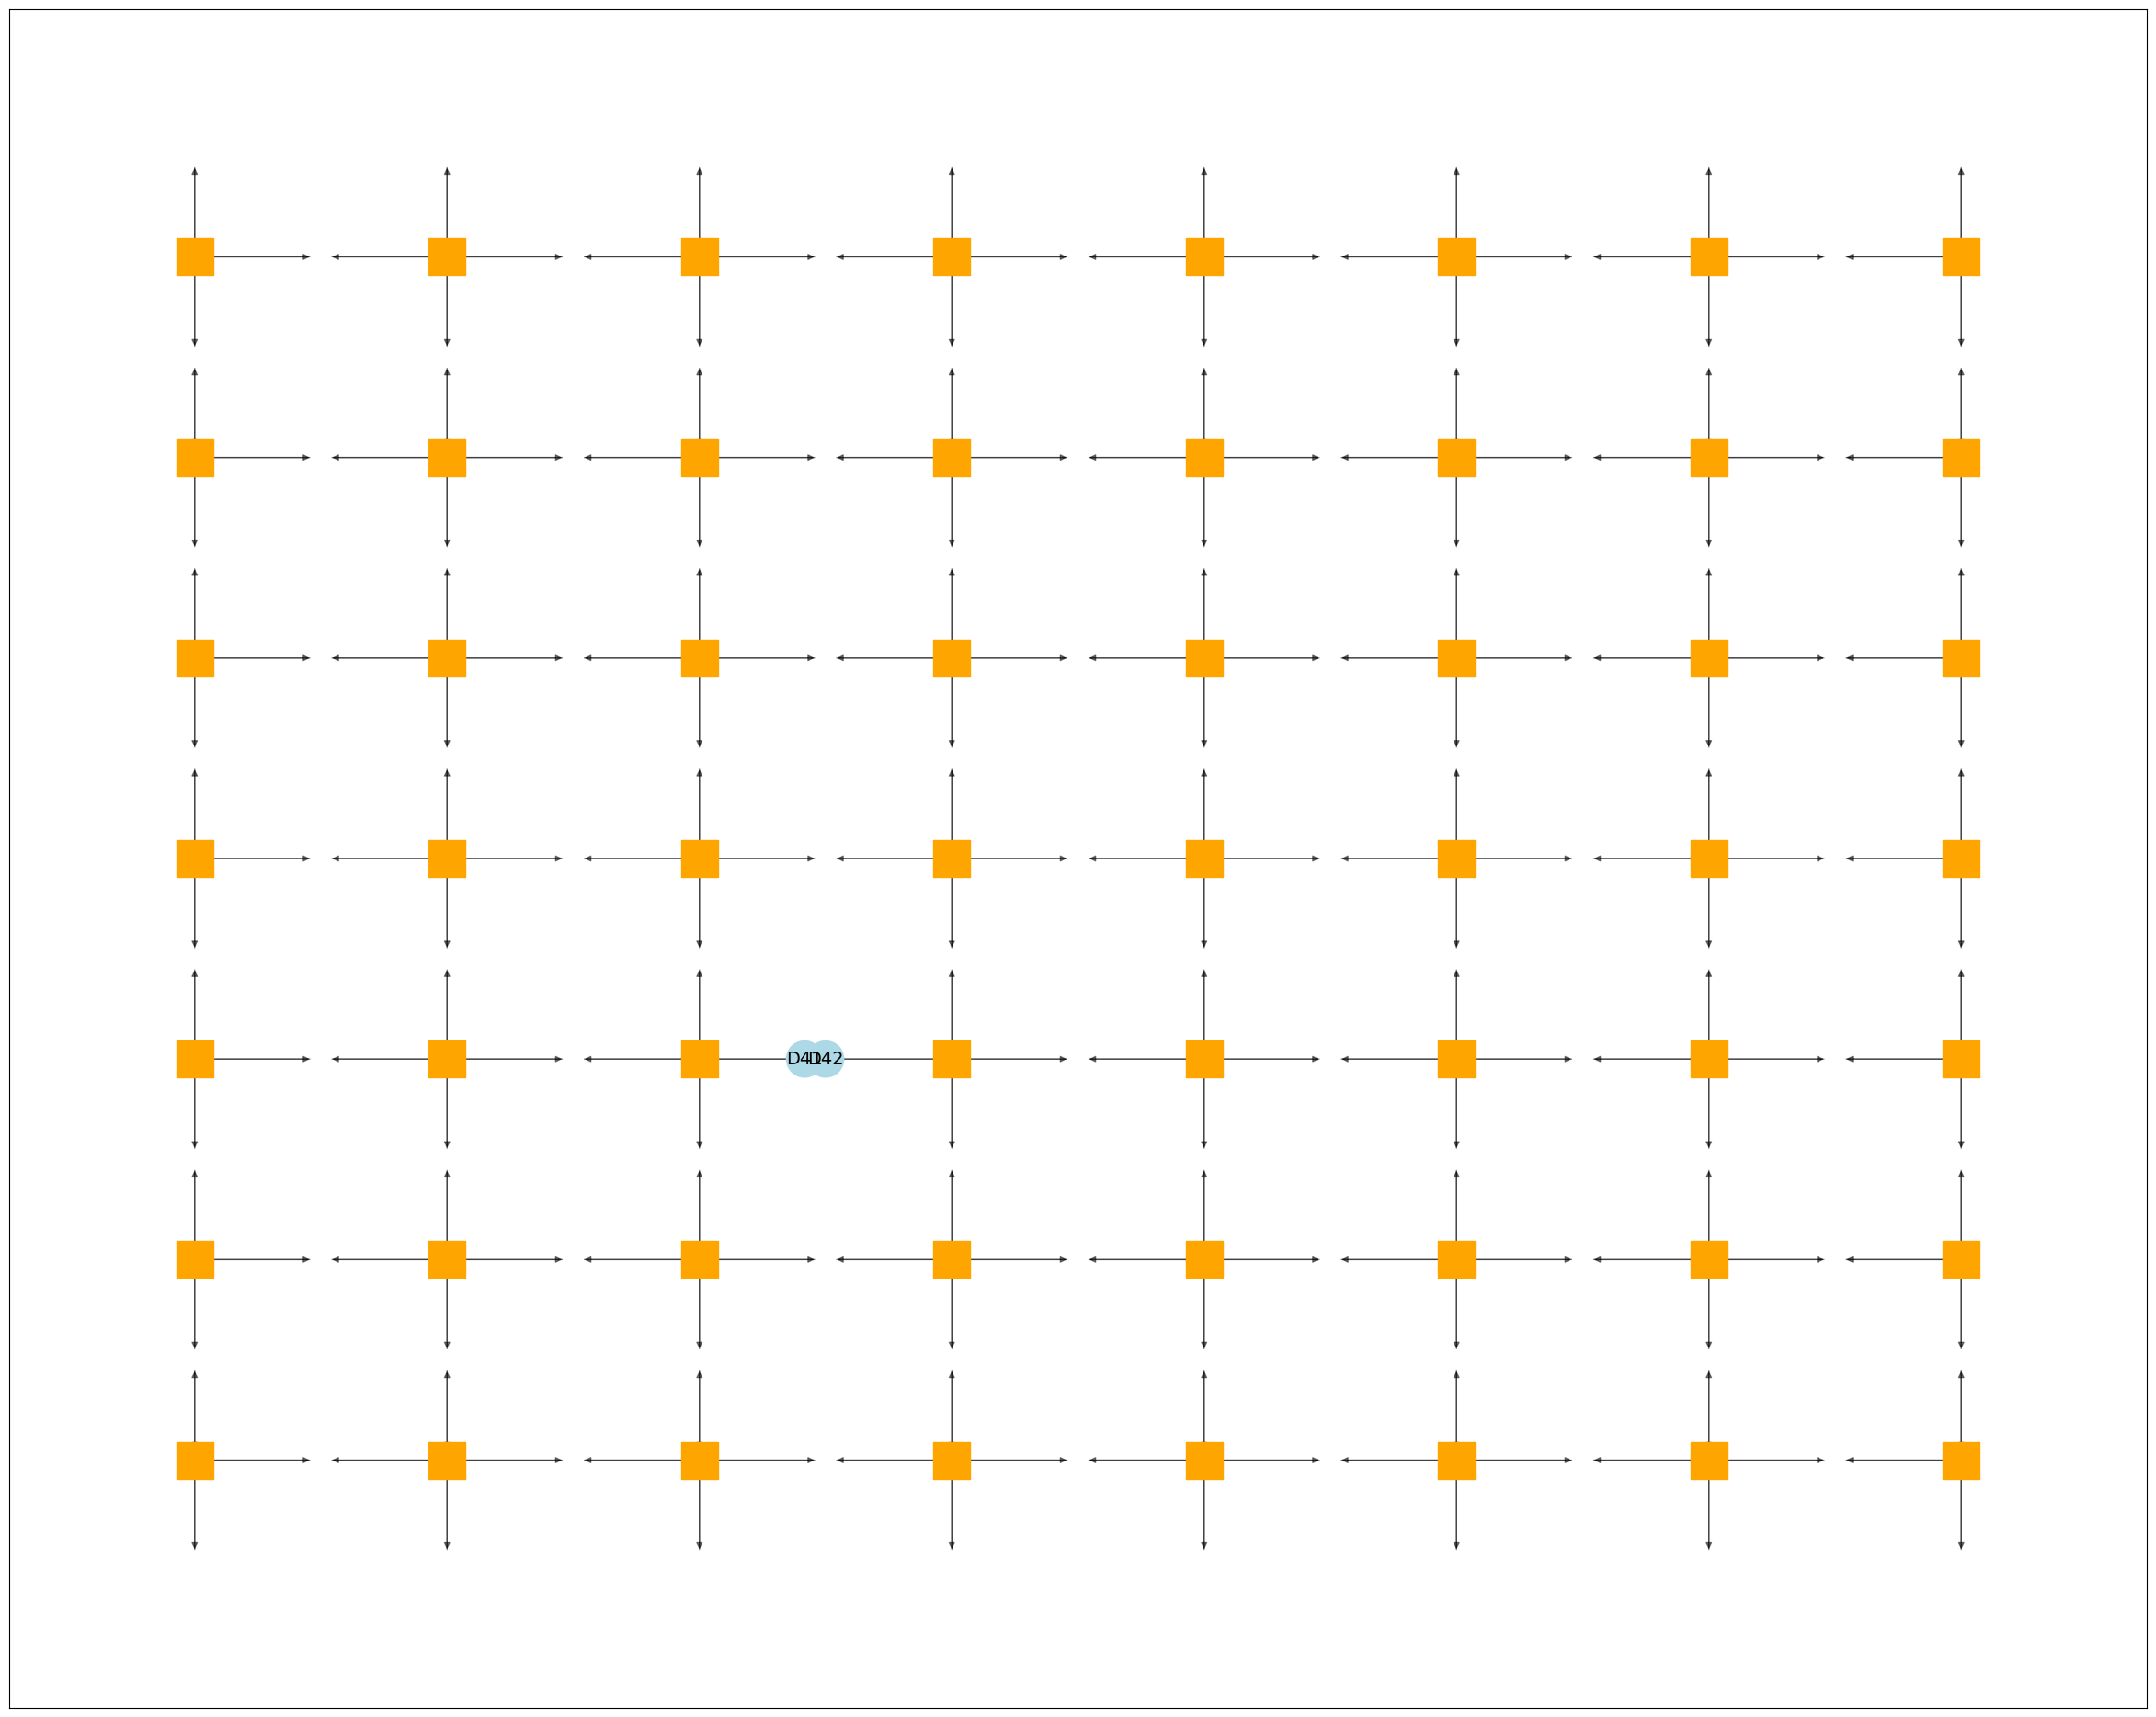

In [7]:
# Manual runs of testing routing
from src.simulator.qccd_circuit import QCCDCircuit
import numpy as np
import matplotlib.pyplot as plt

path = "./color_code_experiments/supersimplecircuit.txt"
path1 = "./color_code_experiments/r=20,d=5,p=0.001,noise=uniform,c=midout_color_code_488_Z,gates=all.stim"
TEST_DISTANCE = 5
TEST_CAPACITY = 2

with open(path, "r") as f:
    raw = f.read()

circuit = QCCDCircuit(raw)
#print(f"circuit: {str(circuit)}")

#s = "17 15 14 13 12 11 10 5 4 3 0"
s = "0 1"
d_qubits = list(int(i) for i in s.strip().split(" "))
circuit.dataQubitsIdxs = list(d_qubits)

qcount = 2

arch, (instructions, _) = circuit.processColorCircuitAugmentedGrid(
    rows=TEST_DISTANCE + 1, 
    cols=TEST_DISTANCE + 1,
    trapCapacity=TEST_CAPACITY, 
    dataQubitIdxs=d_qubits
)
#instructions, barriers = circuit._parseCircuitString(dataQubitsIdxs=d_qubits)

arch.refreshGraph()
print(f"instr n = {len(instructions)}")
print(arch.graph)
fig, ax = plt.subplots()
arch.display(fig,ax, showLabels=False)
print(f"ions in arch: {arch.ions}")
for t in arch._manipulationTraps:
    print(t.ions)
    for i in t.ions:
        print("ion here", i.parent)
print(len(arch.ions))
print(f"measurements = {circuit._measurementIons}, datas = {circuit._dataIons}")
print("finished processing")

# run 
print("running routing")
allOps, barriers = naiveAltIonRouting2(arch, instructions, TEST_CAPACITY)
print("finished routing")
print(f"allOps = {allOps} \n barriers = {barriers}")

instr n = 5822
DiGraph with 190 nodes and 487 edges
ions in arch: {19: <src.utils.qccd_nodes.QubitIon object at 0x000001E331293690>, 20: <src.utils.qccd_nodes.QubitIon object at 0x000001E3312C8730>, 28: <src.utils.qccd_nodes.QubitIon object at 0x000001E32E8BB570>, 29: <src.utils.qccd_nodes.QubitIon object at 0x000001E331201250>, 30: <src.utils.qccd_nodes.QubitIon object at 0x000001E331201350>, 38: <src.utils.qccd_nodes.QubitIon object at 0x000001E32E834710>, 39: <src.utils.qccd_nodes.QubitIon object at 0x000001E33129CF50>, 40: <src.utils.qccd_nodes.QubitIon object at 0x000001E32EA83490>, 41: <src.utils.qccd_nodes.QubitIon object at 0x000001E32EA836F0>, 43: <src.utils.qccd_nodes.QubitIon object at 0x000001E3312DF2F0>, 44: <src.utils.qccd_nodes.QubitIon object at 0x000001E331307790>, 45: <src.utils.qccd_nodes.QubitIon object at 0x000001E3312DF430>, 53: <src.utils.qccd_nodes.QubitIon object at 0x000001E33128AE10>, 54: <src.utils.qccd_nodes.QubitIon object at 0x000001E33128AD50>, 55: <src.

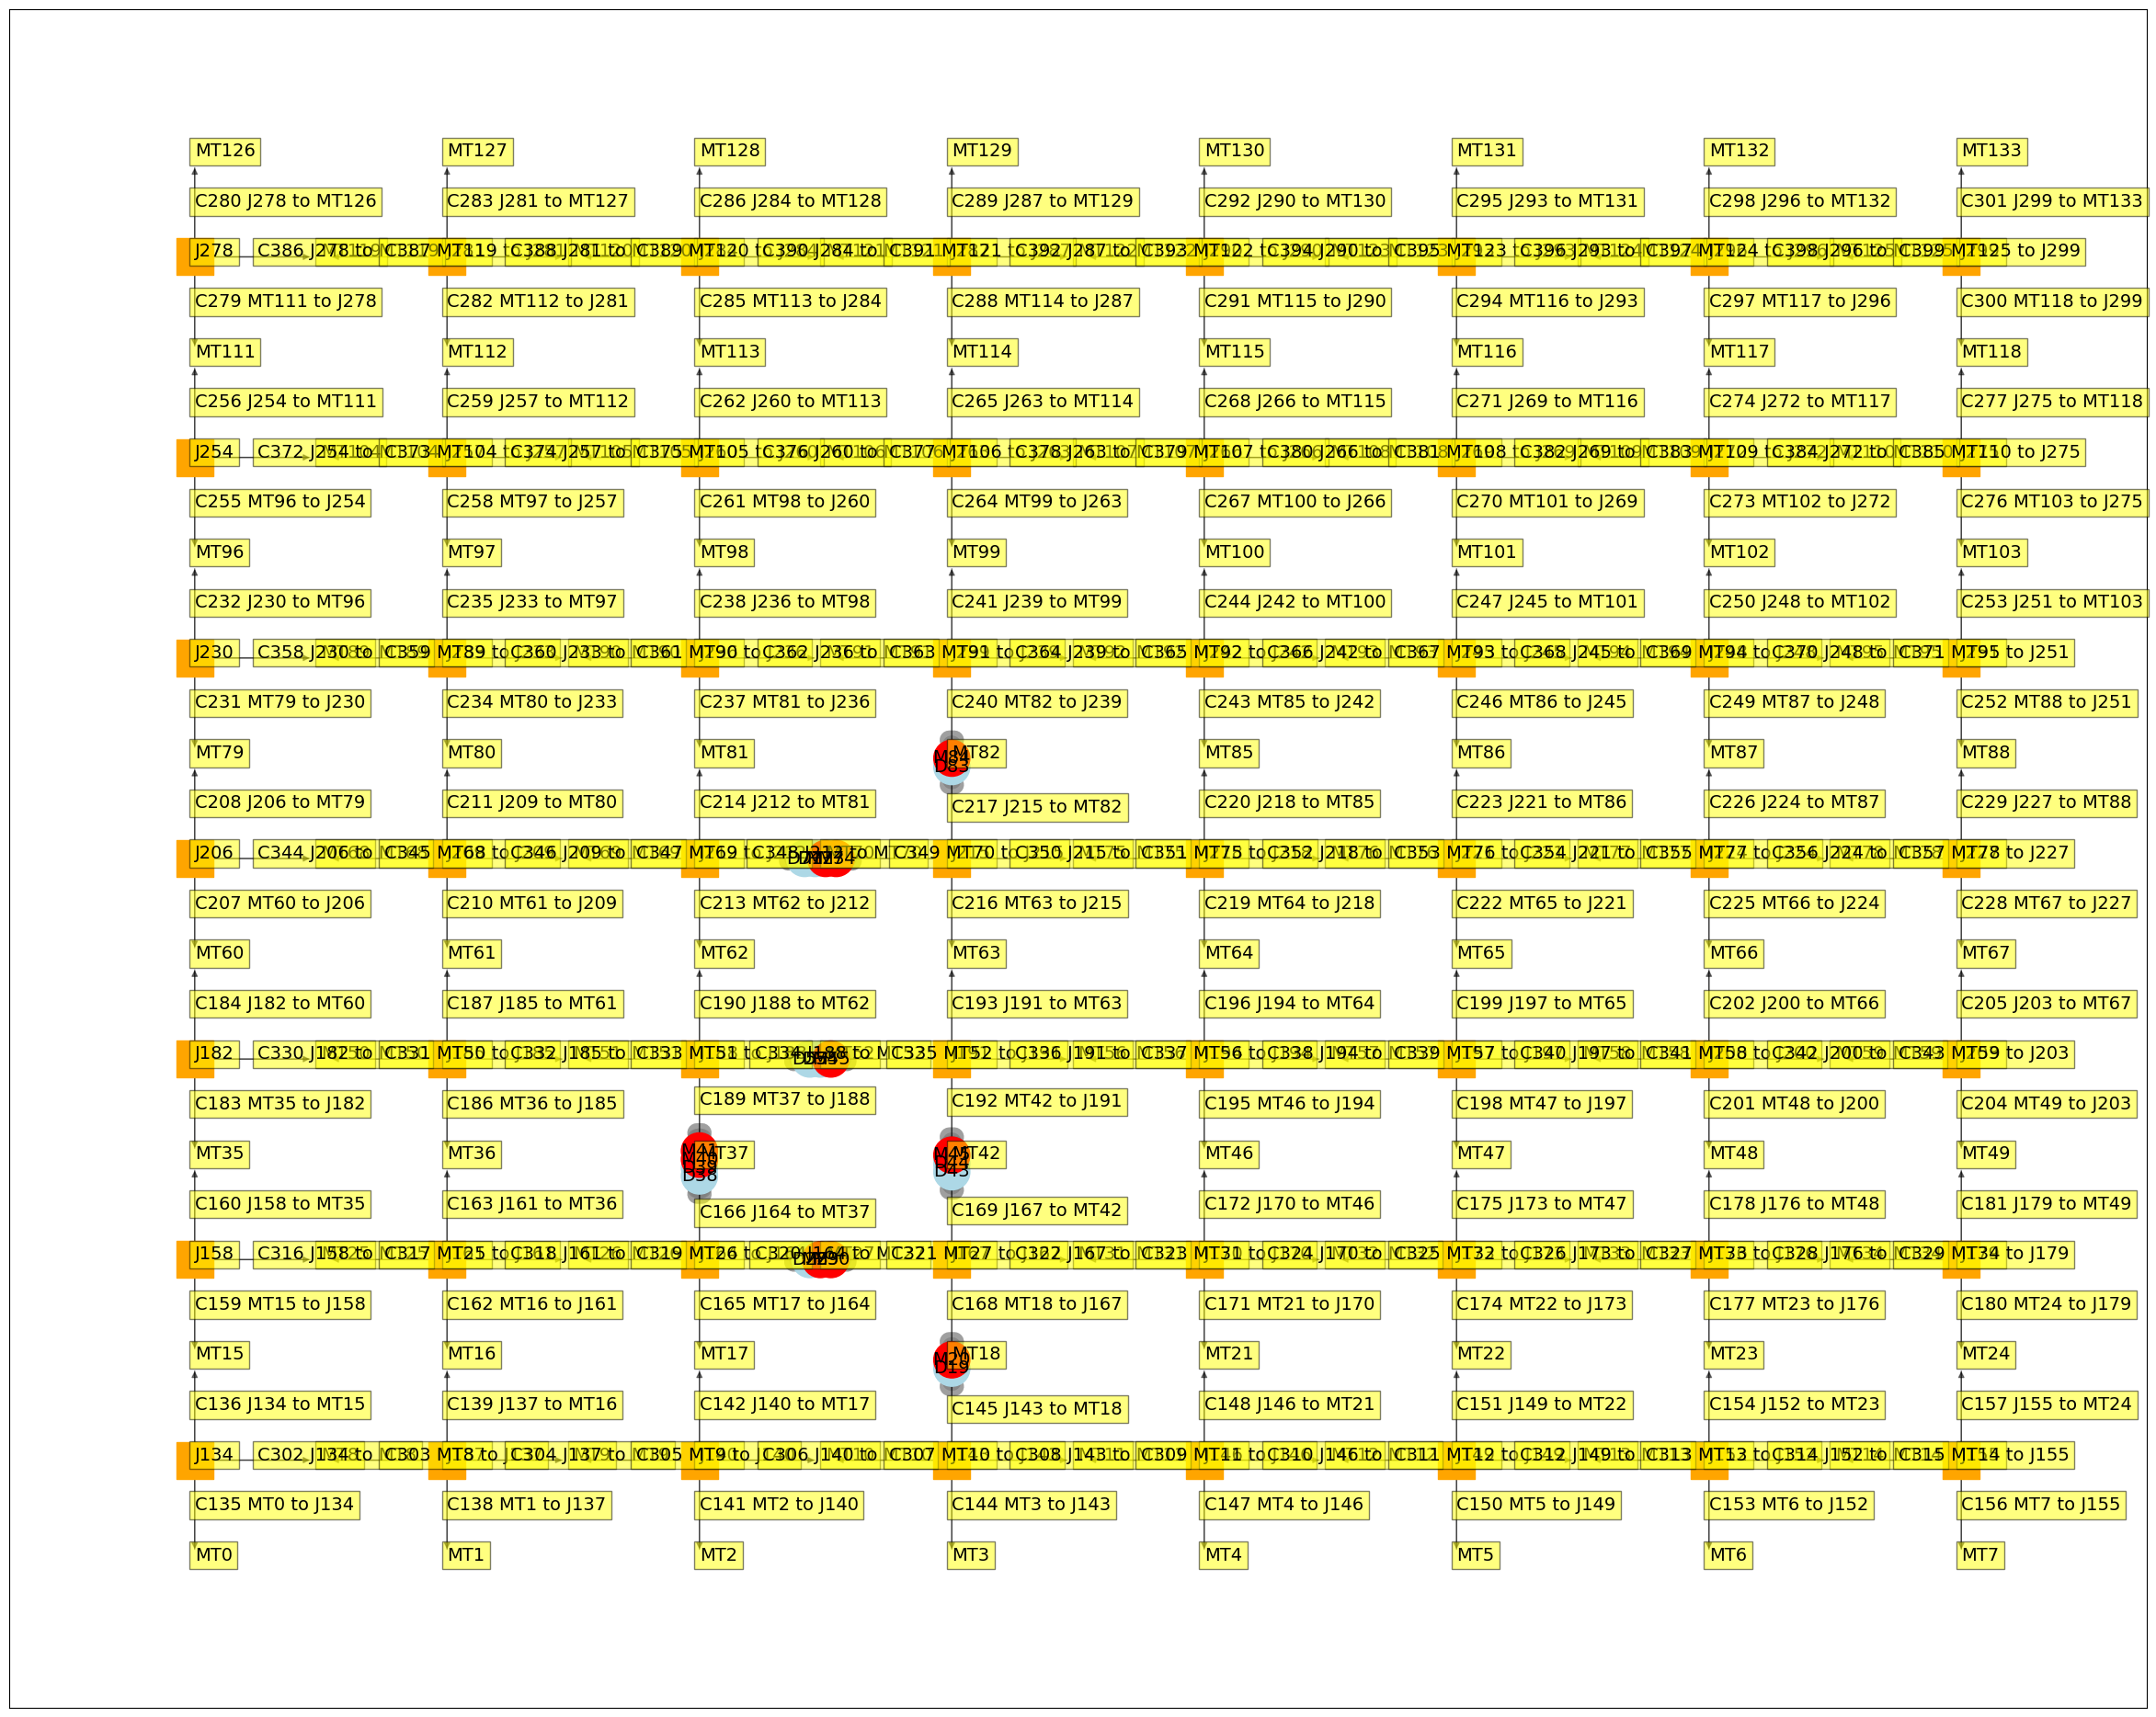

In [8]:
# Manual runs of testing routing with external impl

path = "./color_code_experiments/r=20,d=5,p=0.001,noise=uniform,c=midout_color_code_488_Z,gates=all.stim"
TEST_DISTANCE = 5
TEST_CAPACITY = 5

with open(path, "r") as f:
    raw = f.read()

circuit = QCCDCircuit(raw)
#print(f"circuit: {str(circuit)}")

s = "17 15 14 13 12 11 10 5 4 3 0"
d_qubits = list(int(i) for i in s.strip().split(" "))
circuit.dataQubitsIdxs = list(d_qubits)

qcount = 21

arch, (instructions, _) = circuit.processColorCircuitAugmentedGrid(
    rows=TEST_DISTANCE + 1, 
    cols=TEST_DISTANCE + 1,
    trapCapacity=TEST_CAPACITY, 
    dataQubitIdxs=d_qubits
)
#instructions, barriers = circuit._parseCircuitString(dataQubitsIdxs=d_qubits)

arch.refreshGraph()
print(f"instr n = {len(instructions)}")
print(arch.graph)
fig, ax = plt.subplots()
arch.display(fig,ax, showLabels=True)
print(f"ions in arch: {arch.ions}")
for t in arch._manipulationTraps:
    print(t.ions)
    for i in t.ions:
        print("ion here", i.parent)
print(len(arch.ions))
print(f"measurements = {circuit._measurementIons}, datas = {circuit._dataIons}")
print("finished processing")

# run 
print("running routing")
allOps, barriers = naiveAltIonRouting(arch, instructions, TEST_CAPACITY)
print("finished routing")
print(f"allOps = {allOps} \n barriers = {barriers}")

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D33D66F10>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D33D64940>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D33D66410>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D33D66990>
[]
[]
[]
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B10D0>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B2990>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B3280>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B1230>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B09F0>
[]
[]
[]
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B31D0>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B1A70>
ion here <src.utils.qccd_nodes.ManipulationTrap object at 0x0000018D328B3800

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



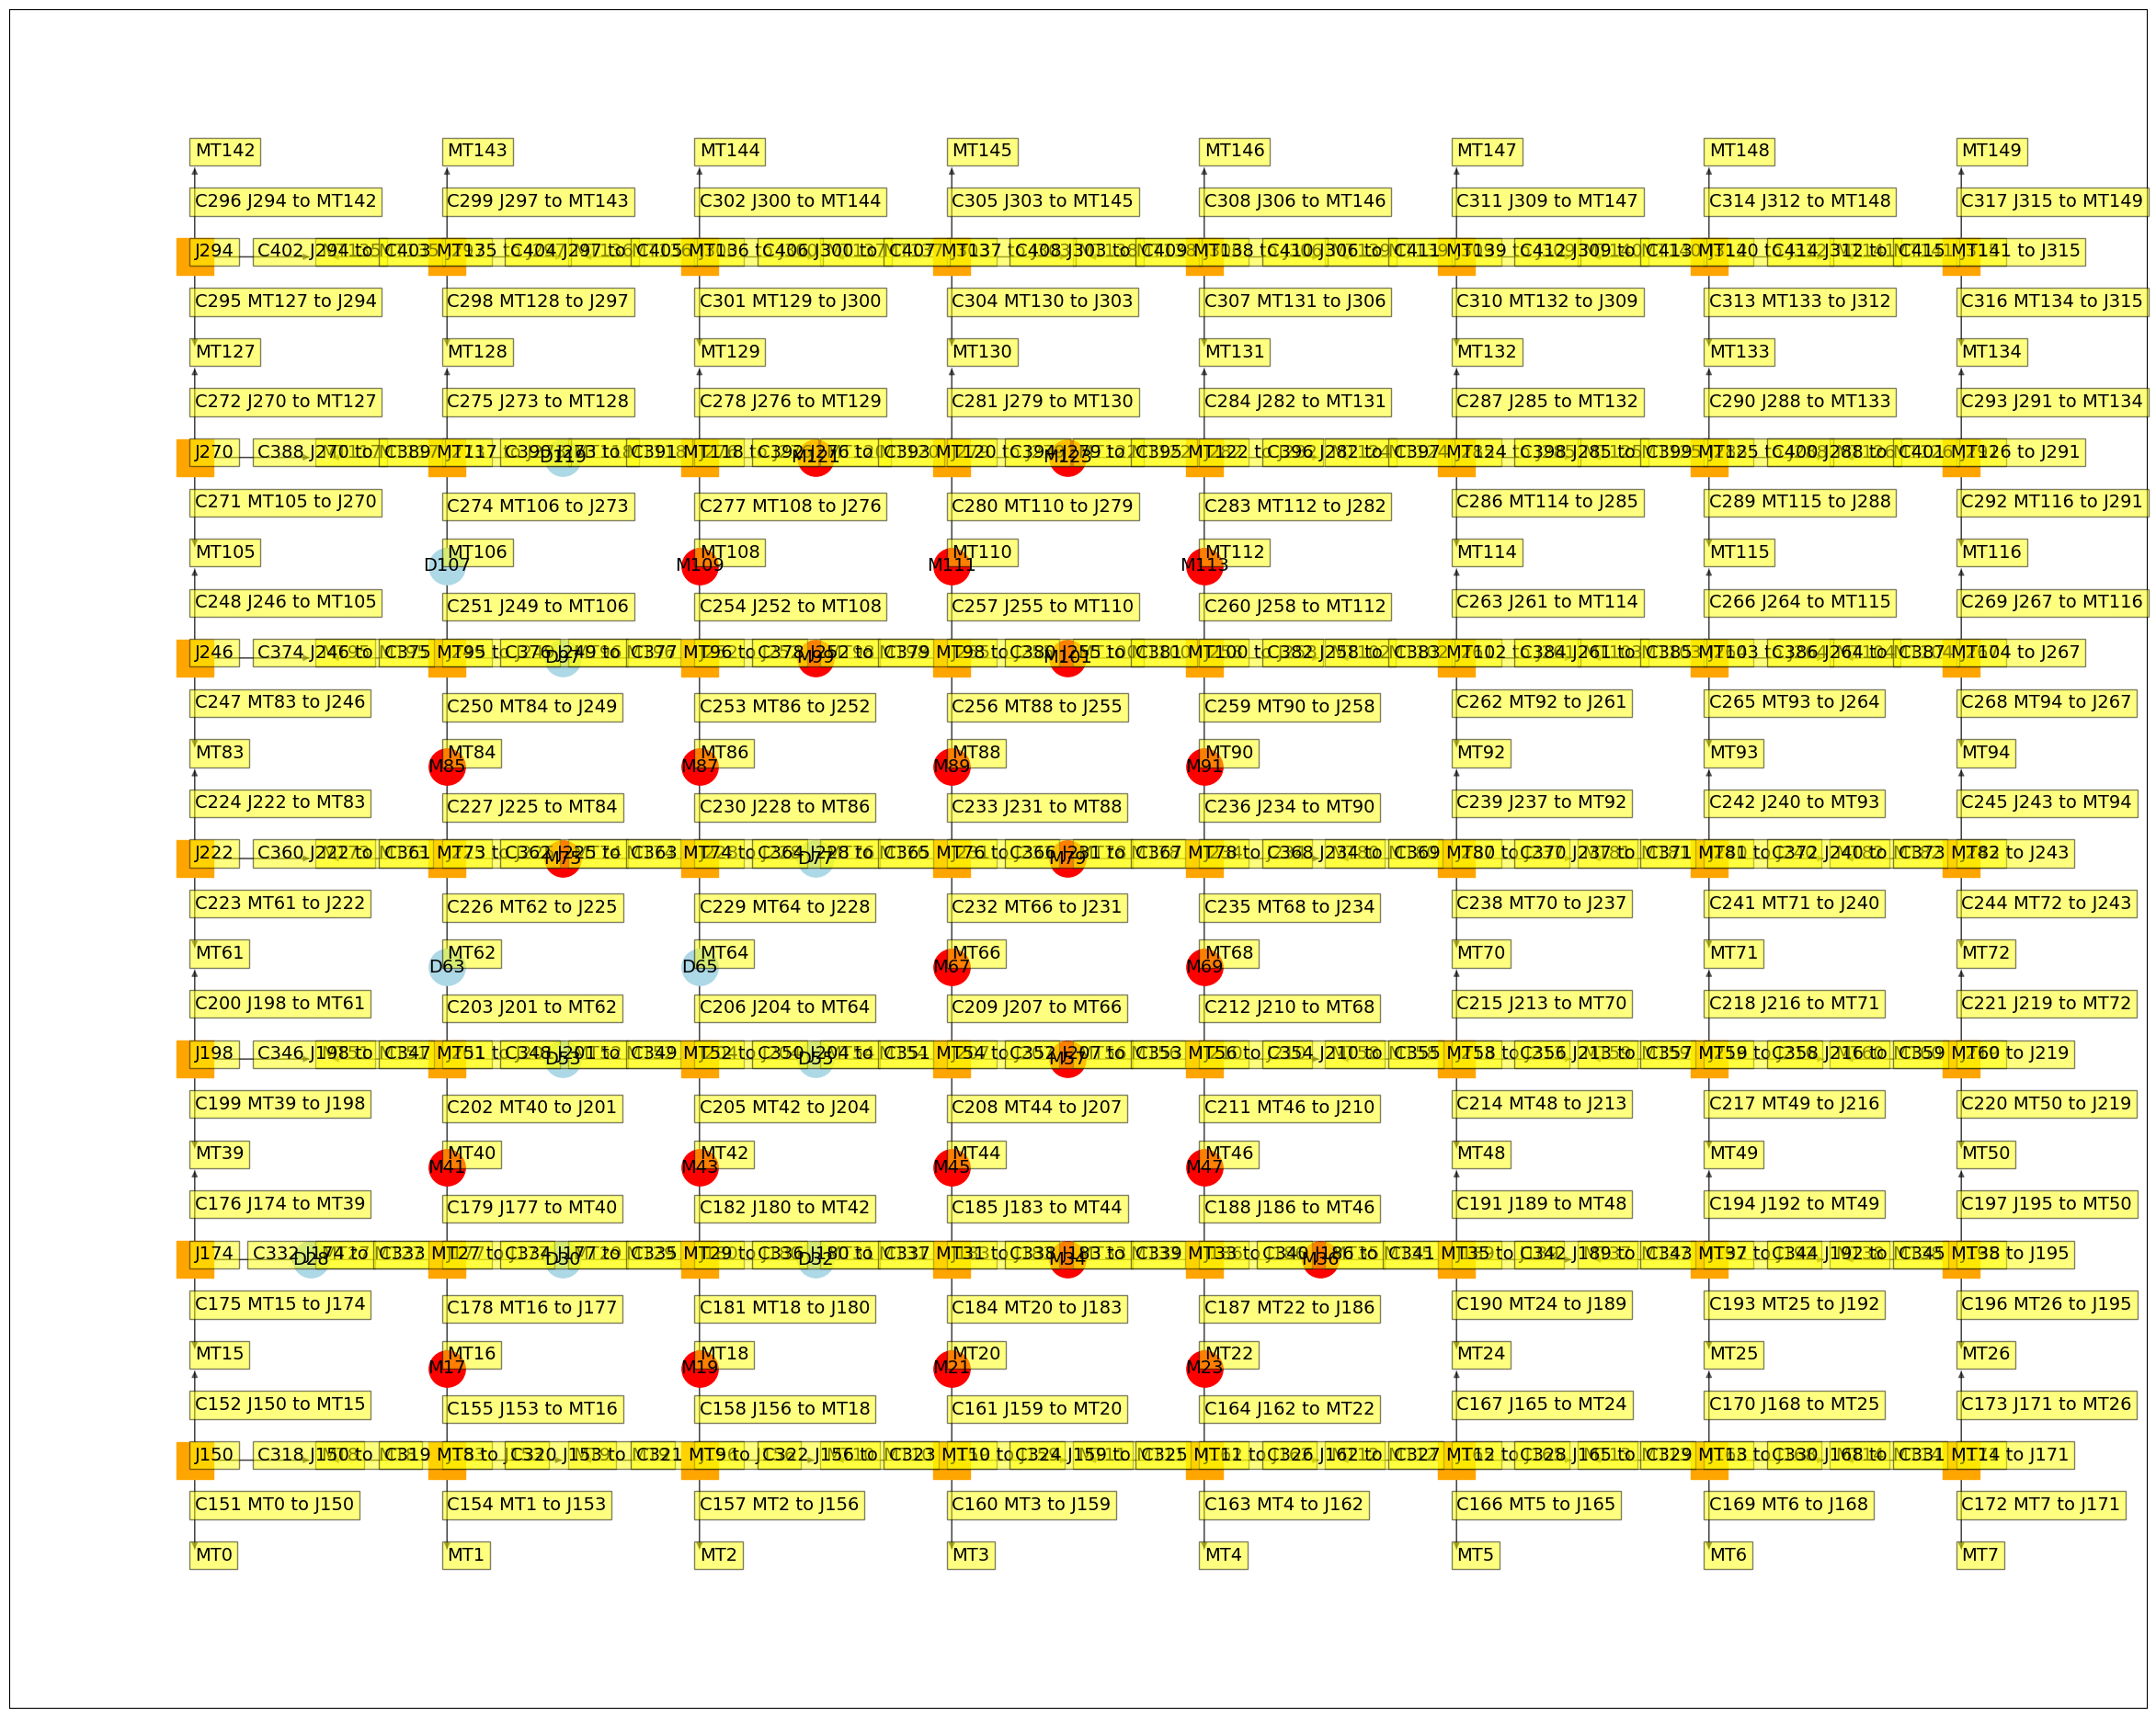

In [14]:

TEST_DISTANCE = 5
TEST_CAPACITY = 2

path = r"./color_code_experiments/superdense_color_code_d5_r20_p1000.stim"

with open(path, "r") as f:
    raw = f.read()
s = "0 2 5 7 8 10 12 14 16 18 20 22 24 26 28 30 32 34 35"
d_qubit_ids = list(int(i) for i in s.strip().split(" "))
qcount = 37

circuit = QCCDCircuit(raw)
circuit.dataQubitsIdxs = list(d_qubit_ids)

arch, (instructions, _) = circuit.processColorCircuitAugmentedGrid(
    rows=TEST_DISTANCE + 1, 
    cols=TEST_DISTANCE + 1,
    trapCapacity=TEST_CAPACITY, 
    dataQubitIdxs=d_qubits
)
#instructions, barriers = circuit._parseCircuitString(dataQubitsIdxs=d_qubits)

arch.refreshGraph()
#print(f"instr n = {len(instructions)}")
#print(arch.graph)
fig, ax = plt.subplots()
arch.display(fig,ax, showLabels=True)
#print(f"ions in arch: {arch.ions}")
for t in arch._manipulationTraps:
    print(t.ions)
    for i in t.ions:
        print("ion here", i.parent)
print(len(arch.ions))
print(f"measurements = {circuit._measurementIons}, datas = {circuit._dataIons}")
print("finished processing")

# run 
print("running routing")
allOps, barriers = naiveAltIonRouting2(arch, instructions, TEST_CAPACITY)
print("finished routing")
print(f"allOps = {allOps} \n barriers = {barriers}")

In [13]:
TEST_DISTANCE = 3
TEST_CAPACITY = 2

circuit = QCCDCircuit.generated(
    "surface_code:rotated_memory_z",
    rounds=1,
    distance=TEST_DISTANCE,
)
arch, (instructions, _) = circuit.processCircuitAugmentedGrid(
    rows=TEST_DISTANCE + 1, 
    cols=TEST_DISTANCE + 1, 
    trapCapacity=TEST_CAPACITY, 
)
arch.refreshGraph()
ops = []



timer = timeit.Timer(lambda: naiveAltIonRouting(arch, instructions, TEST_CAPACITY))
elapsed = timer.timeit(1)
print(f'Time taken: {elapsed:.6f} seconds')

timer = timeit.Timer(lambda: ionRouting(arch, instructions, TEST_CAPACITY))
elapsed = timer.timeit(1)
print(f'Time taken: {elapsed:.6f} seconds')

178
122
93
66
44
23
4
Time taken: 0.246889 seconds
Time taken: 0.225866 seconds
